In [52]:
from collections import defaultdict, Counter
from heapq import heappush, heappop
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

### Task 1

In [3]:
df_train = pd.read_csv('../data/lab03/occupancy_train.txt');

df_train = df_train[['Humidity', 'Light', 'HumidityRatio', 'Occupancy']]

df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 1 to 8143
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Humidity       8143 non-null   float64
 1   Light          8143 non-null   float64
 2   HumidityRatio  8143 non-null   float64
 3   Occupancy      8143 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 318.1 KB


In [4]:
knn = KNeighborsClassifier()

X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [5]:
df_test = pd.read_csv('../data/lab03/occupancy_test.txt')

df_test = df_test[['Humidity', 'Light', 'HumidityRatio', 'Occupancy']]
rows, cols = df_test.shape

X_test = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1]

max_acc_k = -1
accs = defaultdict(float)
for k in range(1, 11):
  knn.set_params(n_neighbors=k)
  result = knn.predict(X_test)
  difference = (y_test == result).value_counts()

  accs[k] = difference[True] / rows * 100
  max_acc_k = max(max_acc_k, k, key=lambda k: accs[k])

  print(f'Accuracy at k = {k}: {accs[k]:.4}%')

print(f'Highest accuracy with k = {max_acc_k}')

Accuracy at k = 1: 94.03%
Accuracy at k = 2: 92.53%
Accuracy at k = 3: 95.72%
Accuracy at k = 4: 94.48%
Accuracy at k = 5: 95.53%
Accuracy at k = 6: 95.27%
Accuracy at k = 7: 96.32%
Accuracy at k = 8: 96.14%
Accuracy at k = 9: 96.47%
Accuracy at k = 10: 96.47%
Highest accuracy with k = 9


### Task 2

In [6]:

# EUCLIDEAN
# def distance(x, y):
#   res = 0
#   for xi, yi in zip(x, y):
#     res += (xi - yi)**2
#   return res**0.5

# CHI SQUARED
def distance(x, y):
  res = 0
  for xi, yi in zip(x, y):
    res += (xi - yi)**2 / (xi + yi)
  return res

def extract_first_k_result(k, pq):
  return max(Counter(heappop(pq)[1] for _ in range(k)).items(), key=lambda x: x[1])[0]

def order_values(X, y, target):
  pq = []
  for row, value in zip(X, y):
    heappush(pq, (distance(row, target), value))
  return pq

def knn(k, X_train, y_train, X_test):
  k = min(k, len(X))

  preds = []
  for row in X_test:
    pq = order_values(X_train, y_train, row)
    value = extract_first_k_result(k, pq)
    preds.append(value)

  return preds

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=727
)

predictions = knn(3, X_train, y_train, X_test)
print(f'Accuracy: {accuracy_score(y_test, predictions) * 100:.4}%')

Accuracy: 96.67%


### Task 3

In [9]:
df = pd.read_csv('../data/cancer_patient_data_sets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [ ]:
# checking if balanced
df.Level.value_counts()

Level
High      365
Medium    332
Low       303
Name: count, dtype: int64

Appears balanced

In [29]:
display(df.duplicated().value_counts()) # checking duplicates

categorical = df.select_dtypes(include='object')
display(categorical.columns)

categorical['Level'].unique()

False    1000
Name: count, dtype: int64

Index(['Patient Id', 'Level'], dtype='object')

array(['Low', 'Medium', 'High'], dtype=object)

No duplicates in the datasets
There are only 2 categorical fields: PatientID and Level. PatientID isn't very useful
None of the values in the dataset are null

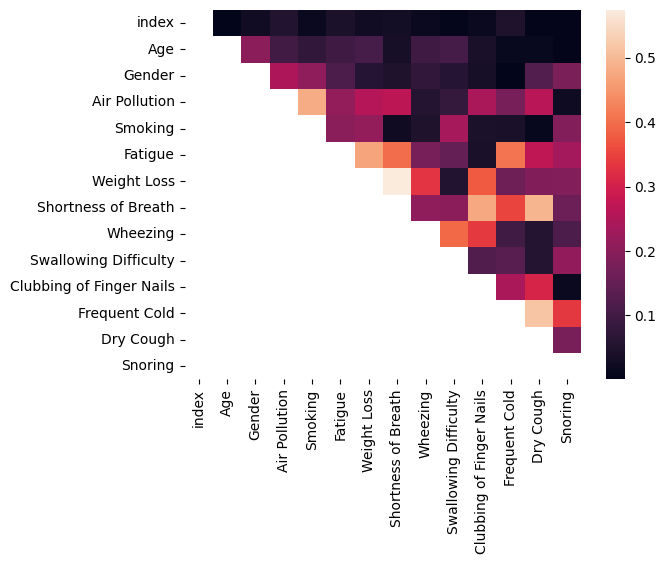

In [ ]:
abs_corr = df.corr(numeric_only=True).abs()

upper = abs_corr.where(
  np.triu(np.ones(abs_corr.shape), k=1).astype(bool)
)

sns.heatmap(upper) # overall not much correlation b/w features

# this won't be dropping any feature
# to_drop = [column for column in upper.columns if any(upper[column] > 0.65)]
# df = df.drop(columns=to_drop)

In [54]:
X = df.iloc[:, 2:-1]
y = df.iloc[:, -1]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=0, stratify=y_encoded)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0, stratify=y_train)

In [56]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_train)
y_pred_val = knn.predict(X_val)

print("Training:", accuracy_score(y_train, y_pred))
print("Validation:", accuracy_score(y_val, y_pred_val))

Training: 1.0
Validation: 1.0


In [57]:
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {}
for metric in metrics:
  knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
  knn.fit(X_train, y_train)
  
  acc_train = accuracy_score(y_train, knn.predict(X_train))
  acc_val = accuracy_score(y_val, knn.predict(X_val))
  
  results[metric] = [acc_train, acc_val]

pd.DataFrame(columns=metrics, index=['Training', 'Validation'], data=results)

,euclidean,manhattan,minkowski
Training,1.0,1.0,1.0
Validation,1.0,1.0,1.0
